In [11]:
import pandas as pd
import numpy as np

# Load dataset (change file name)
df = pd.read_csv("Mall_Customers.csv")

# Keep only numeric columns, excluding CustomerID
data = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID']).dropna()
X = data.to_numpy()

print("Shape of usable data:", X.shape)

Shape of usable data: (200, 3)


In [12]:
import random
import numpy as np
import collections # Import collections for Counter

def kmeans(X, k, max_iter=100):
    n_samples, n_features = X.shape

    # randomly choose k centroids
    centroids = X[np.random.choice(range(n_samples), k, replace=False)]

    for _ in range(max_iter):
        # assign clusters
        clusters = [[] for i in range(k)]
        for x in X:
            distances = [np.linalg.norm(x - c) for c in centroids]
            cluster_id = np.argmin(distances)
            clusters[cluster_id].append(x)

        # update centroids
        new_centroids = np.array([np.mean(cluster, axis=0) if len(cluster) > 0 else centroids[i]
                                  for i, cluster in enumerate(clusters)])

        # stop if converged
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    # final labels
    labels = []
    for x in X:
        distances = [np.linalg.norm(x - c) for c in centroids]
        labels.append(np.argmin(distances))

    return np.array(labels), centroids

# Run
labels_kmeans, centroids = kmeans(X, k=4)
print("K-Means Labels (first 20):", labels_kmeans[:20])
print("K-Means Label Distribution:", collections.Counter(labels_kmeans))


K-Means Labels (first 20): [3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0]
K-Means Label Distribution: Counter({np.int64(0): 100, np.int64(2): 39, np.int64(1): 38, np.int64(3): 23})


In [10]:
import random
import numpy as np
import collections # Import collections for Counter

def dbscan(X, eps, min_samples):
    labels = [0] * len(X)  # 0: unvisited, -1: noise, >0: cluster_id
    cluster_id_counter = 0

    def region_query(point_idx):
        neighbors = []
        for idx, point in enumerate(X):
            if np.linalg.norm(X[point_idx] - point) <= eps: # Corrected < to <=
                neighbors.append(idx)
        return neighbors

    for i in range(len(X)):
        if labels[i] != 0:  # Already visited or assigned to a cluster
            continue

        neighbors = region_query(i)

        if len(neighbors) < min_samples:
            labels[i] = -1  # Mark as noise
        else:
            cluster_id_counter += 1
            seed_set = list(neighbors)

            j = 0
            while j < len(seed_set):
                current_neighbor_idx = seed_set[j]
                j += 1

                if labels[current_neighbor_idx] == -1: # Previously marked as noise, now a border point of this cluster
                    labels[current_neighbor_idx] = cluster_id_counter
                elif labels[current_neighbor_idx] == 0: # Unvisited point
                    labels[current_neighbor_idx] = cluster_id_counter
                    new_neighbors = region_query(current_neighbor_idx)
                    if len(new_neighbors) >= min_samples:
                        # Add only unvisited or noise points to expand
                        seed_set.extend([n for n in new_neighbors if labels[n] == 0 or labels[n] == -1])

    return np.array(labels)

# Run
labels_dbscan = dbscan(X, eps=10.0, min_samples=5) # Adjusted eps for new data scale
print("DBSCAN labels (first 20):", labels_dbscan[:20])
print("DBSCAN Label Distribution:", collections.Counter(labels_dbscan))


DBSCAN labels (first 20): [-1  1 -1  1 -1  1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1  1 -1 -1]
DBSCAN Label Distribution: Counter({np.int64(-1): 127, np.int64(4): 12, np.int64(3): 11, np.int64(1): 9, np.int64(5): 8, np.int64(9): 7, np.int64(6): 6, np.int64(8): 6, np.int64(2): 5, np.int64(10): 5, np.int64(7): 4})


In [21]:
from sklearn.metrics import silhouette_score
import numpy as np

# Assuming X is the data used for clustering

print("--- Silhouette Scores for Custom Algorithms ---")

# K-Means
try:
    sil_kmeans_custom = silhouette_score(X, labels_kmeans)
    print("Silhouette Score (Custom K-Means):", sil_kmeans_custom)
except Exception as e:
    print(f"Could not calculate Silhouette Score for Custom K-Means: {e}")

# DBSCAN
# Filter out noise points (-1) before calculating silhouette score if present
unique_dbscan_labels = np.unique(labels_dbscan)
n_dbscan_clusters = len(unique_dbscan_labels) - (1 if -1 in unique_dbscan_labels else 0)

if n_dbscan_clusters > 1:
    try:
        sil_dbscan_custom = silhouette_score(X, labels_dbscan)
        print("Silhouette Score (Custom DBSCAN):", sil_dbscan_custom)
    except Exception as e:
        print(f"Could not calculate Silhouette Score for Custom DBSCAN: {e}")
else:
    print("Custom DBSCAN found too few clusters (or only noise) to compute silhouette score.")

# Agglomerative
try:
    sil_aggl_custom = silhouette_score(X, labels_aggl)
    print("Silhouette Score (Custom Agglomerative):", sil_aggl_custom)
except Exception as e:
    print(f"Could not calculate Silhouette Score for Custom Agglomerative: {e}")

# Divisive
try:
    sil_divisive_custom = silhouette_score(X, labels_divisive)
    print("Silhouette Score (Custom Divisive):", sil_divisive_custom)
except Exception as e:
    print(f"Could not calculate Silhouette Score for Custom Divisive: {e}")

--- Silhouette Scores for Custom Algorithms ---
Silhouette Score (Custom K-Means): 0.39219951374758283
Silhouette Score (Custom DBSCAN): -0.15303135739278997
Silhouette Score (Custom Agglomerative): 0.18818573744010006
Silhouette Score (Custom Divisive): 0.3183781755536452


In [13]:
import numpy as np
import collections # Import collections for Counter

def agglomerative(X, k):
    clusters = [[i] for i in range(len(X))]

    # Simple single linkage distance (distance between the first points of two clusters)
    def distance(c1, c2):
        # You might want to implement different linkage methods here (e.g., single, complete, average)
        # For simplicity, using distance between the first points as in the original code
        return np.linalg.norm(X[c1[0]] - X[c2[0]])

    while len(clusters) > k:
        min_dist = float('inf')
        merge_a, merge_b = 0, 0

        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                d = distance(clusters[i], clusters[j])
                if d < min_dist:
                    min_dist = d
                    merge_a, merge_b = i, j

        # Merge clusters
        new_cluster = clusters[merge_a] + clusters[merge_b]

        # Remove old clusters and add new one
        # Ensure we remove the higher index first to avoid index out of bounds
        if merge_a > merge_b:
            clusters.pop(merge_a)
            clusters.pop(merge_b)
        else:
            clusters.pop(merge_b)
            clusters.pop(merge_a)
        clusters.append(new_cluster)

    labels = [0] * len(X)
    for idx, cluster in enumerate(clusters):
        for point_idx in cluster:
            labels[point_idx] = idx

    return np.array(labels)

labels_aggl = agglomerative(X, k=4)
print("Agglomerative labels (first 20):", labels_aggl[:20])
print("Agglomerative Label Distribution:", collections.Counter(labels_aggl))


Agglomerative labels (first 20): [2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0]
Agglomerative Label Distribution: Counter({np.int64(3): 100, np.int64(2): 77, np.int64(0): 20, np.int64(1): 3})


In [14]:
import numpy as np
import collections # Import collections for Counter

def divisive_clustering(X, k):
    # Assumes kmeans function is available globally or passed in

    # Start with all points in one cluster
    clusters = [list(range(len(X)))]

    while len(clusters) < k:
        # Find the largest cluster to split
        largest_cluster_indices = max(clusters, key=len)
        clusters.remove(largest_cluster_indices)

        # Extract data subset for the largest cluster
        data_subset = X[largest_cluster_indices]

        # Split this cluster into two using k-means (k=2)
        # It's important to pass the kmeans function or ensure it's globally accessible.
        # Assuming `kmeans` from a previous cell is globally available.
        temp_labels, _ = kmeans(data_subset, 2)

        # Create the two new clusters based on kmeans results
        c1 = [largest_cluster_indices[i] for i in range(len(temp_labels)) if temp_labels[i] == 0]
        c2 = [largest_cluster_indices[i] for i in range(len(temp_labels)) if temp_labels[i] == 1]

        # Add the two new clusters back to the list of clusters
        if len(c1) > 0: # Only add if not empty
            clusters.append(c1)
        if len(c2) > 0: # Only add if not empty
            clusters.append(c2)

        # Handle cases where k-means might not produce 2 distinct clusters
        # This could happen if all points in the subset are identical, or k-means fails
        if len(clusters) == len(clusters) - 1 and len(clusters) < k: # If no split occurred, break to prevent infinite loop
            break

    # Assign final labels to original data points
    final_labels = [0] * len(X)
    for idx, cluster in enumerate(clusters):
        for point_idx in cluster:
            final_labels[point_idx] = idx

    return np.array(final_labels)

labels_divisive = divisive_clustering(X, k=4)
print("Divisive Labels (first 20):", labels_divisive[:20])
print("Divisive Label Distribution:", collections.Counter(labels_divisive))


Divisive Labels (first 20): [2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 3 2 0 2]
Divisive Label Distribution: Counter({np.int64(3): 70, np.int64(0): 66, np.int64(1): 39, np.int64(2): 25})


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'data' DataFrame has the columns needed for plotting
# 'Annual Income (k$)' and 'Spending Score (1-100)'
# The 'data' DataFrame was created in the first cell, FUXkQArqRSaw
annual_income = data['Annual Income (k$)']
spending_score = data['Spending Score (1-100)']

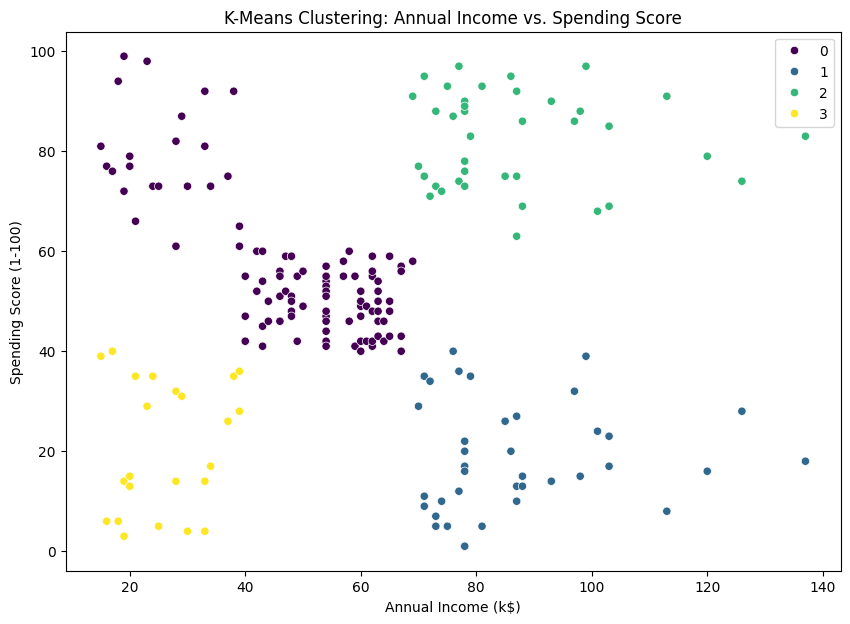

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=annual_income, y=spending_score, hue=labels_kmeans, palette='viridis', legend='full')
plt.title('K-Means Clustering: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

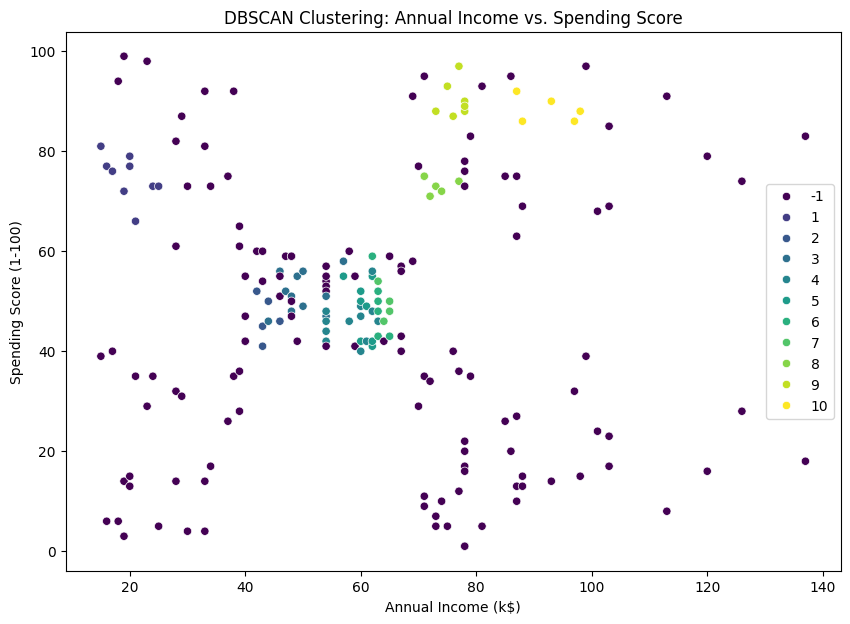

In [17]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=annual_income, y=spending_score, hue=labels_dbscan, palette='viridis', legend='full')
plt.title('DBSCAN Clustering: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

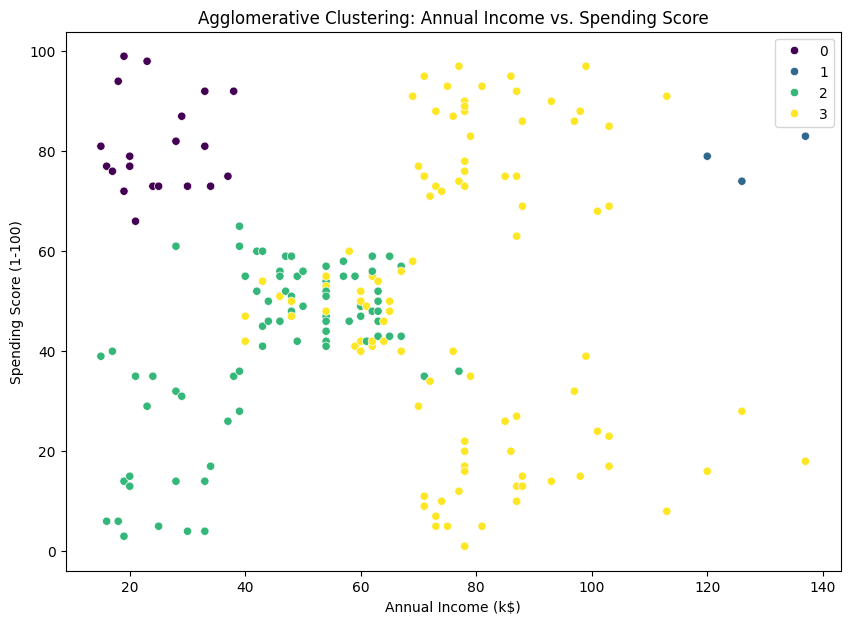

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=annual_income, y=spending_score, hue=labels_aggl, palette='viridis', legend='full')
plt.title('Agglomerative Clustering: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

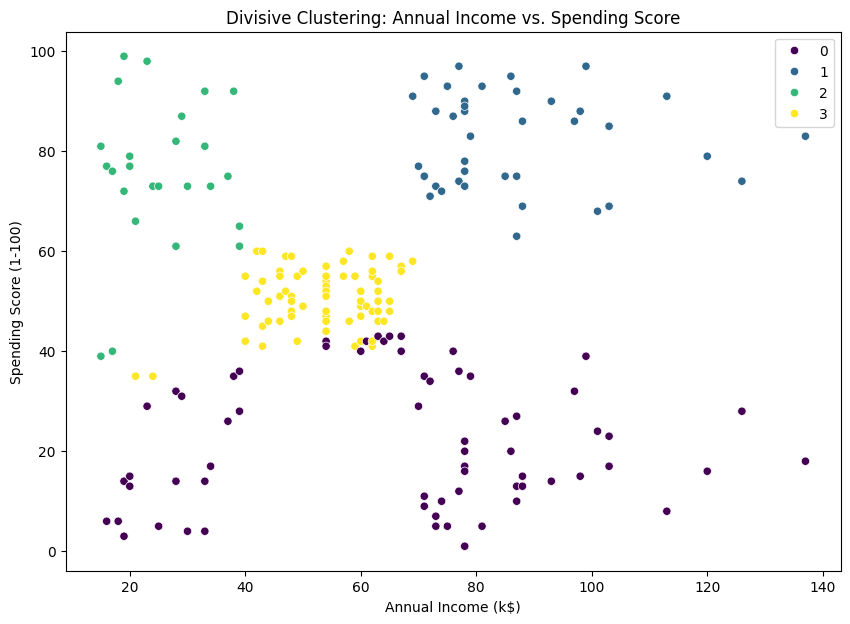

In [19]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=annual_income, y=spending_score, hue=labels_divisive, palette='viridis', legend='full')
plt.title('Divisive Clustering: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

K-Means cluster centers (scaled):
[[-0.01343038  1.13750203 -0.5213944  -0.39856802]
 [ 0.29862851  0.17329545  1.06645385 -1.2980103 ]
 [ 1.12815215 -0.72911539  0.01315937  0.77791013]
 [-0.88640526 -0.67998938 -0.08638219  0.55272197]]
DBSCAN labels counts:
1    112
0     88
Name: count, dtype: int64
Silhouette Score (K-Means): 0.29010917402310876
Silhouette Score (DBSCAN): 0.2776035125578272


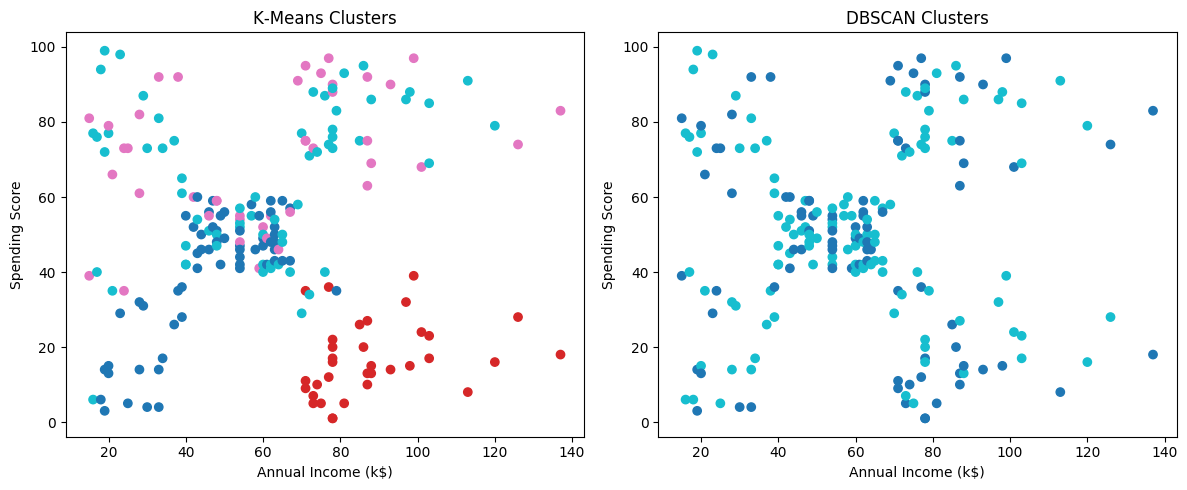

In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# 2. Preprocess
# Drop CustomerID (not useful for clustering)
df2 = df.drop(columns=["CustomerID"])

# Encode Gender (categorical) to numeric
le = LabelEncoder()
df2["Gender"] = le.fit_transform(df2["Gender"])  # Female=0, Male=1 (or similar)

# Select features for clustering
X = df2.values  # Age, Gender, Annual Income, Spending Score

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K‑Means Clustering
k = 4  # or try different k
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means cluster centers (scaled):")
print(kmeans.cluster_centers_)

# 4. DBSCAN Clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)
# Note: eps is sensitive; you may need to tune it
dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN labels counts:")
print(pd.Series(dbscan_labels).value_counts())

# 5. Evaluate (Silhouette Score)
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
print("Silhouette Score (K-Means):", sil_kmeans)

# For DBSCAN: check number of clusters first
n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_db_clusters > 1:
    sil_db = silhouette_score(X_scaled, dbscan_labels)
    print("Silhouette Score (DBSCAN):", sil_db)
else:
    print("DBSCAN found too few clusters to compute silhouette.")

# 6. Visualize Clusters (two features, e.g. Annual Income vs Spending Score)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df2["Annual Income (k$)"], df2["Spending Score (1-100)"], c=kmeans_labels, cmap="tab10")
plt.title("K‑Means Clusters")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.subplot(1, 2, 2)
plt.scatter(df2["Annual Income (k$)"], df2["Spending Score (1-100)"], c=dbscan_labels, cmap="tab10")
plt.title("DBSCAN Clusters")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.tight_layout()
plt.show()
